In [2]:
import sys
import os
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import uuid
import warnings
import gc
# import platform
warnings.filterwarnings('ignore')


# if(platform.system() == "Linux"):
#     project_path = "/mnt/c/Studies/Other_Repos/ts_foundational_models_daily_crpytocurrency_predictions"
#     sys.path.append(os.path.abspath(project_path))
sys.path.append(os.path.abspath(".."))

In [3]:
import pandas as pd
import numpy as np
import json

from src.data_loading import load_crypto_data, preprocess_data, split_data
from src.evaluate_forecasts import evaluate_forecast_one_symbol
from models.arima_wrapper import AutoARIMAWrapper
import os
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from config.config import DATA_DIR
import time
import uuid

DATA_DIR = os.path.join('../data')
OUTPUTS_DIR = os.path.join(DATA_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

Model initialized: AutoARIMA
{'D': None, 'alpha': 0.05, 'concentrate_scale': False, 'd': None, 'enforce_invertibility': True, 'enforce_stationarity': True, 'error_action': 'warn', 'hamilton_representation': False, 'information_criterion': 'aic', 'max_D': 1, 'max_P': 2, 'max_Q': 2, 'max_d': 2, 'max_order': 5, 'max_p': 5, 'max_q': 5, 'maxiter': 50, 'measurement_error': False, 'method': 'lbfgs', 'mle_regression': True, 'n_fits': 10, 'n_jobs': 1, 'offset_test_args': None, 'out_of_sample_size': 0, 'random': False, 'random_state': None, 'scoring': 'mse', 'scoring_args': None, 'seasonal': True, 'seasonal_test': 'ocsb', 'seasonal_test_args': None, 'simple_differencing': False, 'sp': 1, 'start_P': 1, 'start_Q': 1, 'start_p': 2, 'start_params': None, 'start_q': 2, 'stationary': False, 'stepwise': True, 'suppress_warnings': True, 'test': 'kpss', 'time_varying_regression': False, 'trace': False, 'trend': None, 'update_pdq': True, 'with_intercept': True}
AutoARIMA model fitted.
ARIMA Point Forecast

/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


PermissionError: [Errno 13] Permission denied: '../data'

In [33]:
DATA_DIR

'../data'

In [34]:
# Plotting using seaborn and matplotlib

def plot_actual_vs_forecast_for_a_symbol(symbol, plot_data):
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(data=plot_data['Close'], label='Actual Close')
    if "Forecasted_Close" in plot_data.columns:
        sns.lineplot(data=plot_data['Forecasted_Close'], label='Forecasted Close')
    
    plt.title(f'{symbol} : Actual vs. Forecasted Close Values')
    plt.xlabel('Date')
    plt.ylabel('Close Value')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [35]:
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
data_dir = DATA_DIR
train_end_date = "2023-12-31"
horizon = 30
freq = 'D'
scaling = None

In [36]:
debug = False

In [37]:
def forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 365, freq='D', scaling = None):
    """Forecasts cryptocurrency prices and saves results with weekly predictions.

    Args:
        crypto_symbols (list): List of cryptocurrency symbols.
        data_dir (str): Path to the raw data directory.
        train_end_date (str): Date string for the end of the training period.
        horizon (int): Number of next time series to be predicted
        scaling (str): "S" for standard scaler, "M" for Min Max scaler, None for no scaling

    Returns:
        dict: Dictionary containing DataFrames with actual and forecasted values.
    """
    start_time = time.time()
    uuid_name = str(uuid.uuid4())
    print(uuid_name)
    hparams = timesfm.TimesFmHparams(horizon_len=horizon
                                    ,context_len=512
                                    ,input_patch_len=32
                                    ,output_patch_len=128
                                    ,num_layers=20
                                    ,model_dims=1280
                                    ,backend = "gpu"
                                     )
    scaler = None
    if(scaling is not None and scaling.lower() == "s"):
        scaler = StandardScaler()
    elif(scaling is not None and scaling.lower() == "m"):
        scaler = MinMaxScaler()

    forecaster = TimesFMForecaster(hparams = hparams)


        
    for symbol in crypto_symbols:
        file_path = os.path.join(data_dir, 'raw', f'{symbol}.csv')
        df = load_crypto_data(file_path)
        if df is None:
            continue

        processed_df  = preprocess_data(df)
        if processed_df is None:
            continue

        train_df, test_df = split_data(processed_df, train_end_date)
        
        if(debug == True):
            test_df = test_df.head(10)


        if train_df.empty:
            print(f"Warning: No training data available for {symbol}.")
            continue

        if  scaler is not None:
            scaler.fit(train_df[["Close"]])
            train_df[["Close"]] = scaler.transform(train_df[["Close"]])
            test_df[["Close"]] = scaler.transform(test_df[["Close"]])
            if(debug == True):
                print(f"train_last10\n{train_df.tail(10)}")
                print(f"Test all: {test_df}")


        frequency_input = [0]

        # Forecast for the training data (validation)
        train_forecasts = []
        train_forecast_dates = []
        # for i in range(0, len(train_df) - horizon, horizon):
        #     train_history = train_df['Close'].values[:i + 1].astype(np.float32)
        #     train_history_list = [train_history]
        #     try:
        #         point_forecast, _ = forecaster.forecast(train_history_list, frequency_input)
        #         train_forecasts.extend(point_forecast[0])
        #         train_forecast_dates.extend(pd.date_range(start=train_df.index[i + 1], periods=horizon, freq=freq))
        #     except Exception as e:
        #         print(f"Error during training forecast for {symbol} at index {i}: {e}")
        #         break # stop forecasting on train data if an error occurs


        # Forecast for the test data
        test_forecasts = []
        test_forecast_dates = []
        for i in range(0, len(test_df), horizon):
            test_history = pd.concat([train_df['Close'], test_df['Close'][:i]])
            if(debug == True):
                print(f"test_history\n{test_history}")
            test_history = test_history.values.astype(np.float32)
            test_history_list = [test_history]
            try:
                point_forecast, _ = forecaster.forecast(test_history_list, frequency_input)
                test_forecasts.extend(point_forecast[0])
                test_forecast_dates.extend(pd.date_range(start=test_df.index[i], periods=horizon, freq='D'))
            except Exception as e:
                print(f"Error during test forecast for {symbol} at index {i}: {e}")
                break

        if train_forecasts:
            train_forecast_df = pd.DataFrame({'Close': train_forecasts}, index=train_forecast_dates)
            if scaler is not None:
                train_forecast_df["Close"] = scaler.inverse_transform(train_forecast_df[["Close"]])
            train_forecast_df.columns = ["Forecasted_Close"]
            if scaler is not None:
                train_df['Close'] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].join(train_forecast_df, how='left')
        else:
            if scaler is not None:
                train_df[['Close']] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].copy()
            train_output_df['Forecasted_Close'] = np.nan

        if test_forecasts:
            test_forecast_df = pd.DataFrame({'Close': test_forecasts[:len(test_df)]}, index=test_df.index)
            if(debug == True):
                print(f"test_forecast_df\n{test_forecast_df}")
            if scaler is not None:
                test_forecast_df["Close"] = scaler.inverse_transform(test_forecast_df[["Close"]])
                if(debug == True):
                    print(f"test_forecast_df inverse transformed\n{test_forecast_df}")
            test_forecast_df.columns = ["Forecasted_Close"]
            if(debug == True):
                print(f"test_df\n{test_df['Close']}")
            if scaler is not None:
                test_df['Close'] = scaler.inverse_transform(test_df[['Close']])
                if(debug == True):
                    print(f"test_df inverse transformed\n{test_df['Close']}")
            test_output_df = test_df[['Close']].join(test_forecast_df, how='left')
        else:
            if scaler is not None:
                test_df[['Close']] = scaler.inverse_transform(test_df[['Close']])
            test_output_df = test_df[['Close']].copy()
            test_output_df['Forecasted_Close'] = np.nan
        # Save actual and forecasted values (both train and test)
        output_file_path = os.path.join(OUTPUTS_DIR, f'{symbol}_timesfm_{horizon}_{uuid_name}_forecasts.csv')

        combined_data = pd.concat([train_output_df, test_output_df])

        if scaler is not None:
            combined_data["Close_Scaled"] = scaler.transform(combined_data[['Close']])
            forecasted_df = pd.DataFrame(combined_data['Forecasted_Close'], index=combined_data.index)
            forecasted_df.columns = ["Close"]
            combined_data["Forecasted_Close_Scaled"] = scaler.transform(forecasted_df[['Close']])
        end_time = time.time()
        print(f"Execution time for forecast_crypto_prices(): {end_time - start_time} seconds")
        combined_data.to_csv(output_file_path)

        unscaled_data = combined_data[["Close", "Forecasted_Close"]].copy()
        plot_actual_vs_forecast_for_a_symbol(symbol, unscaled_data)
        eval_metrics = evaluate_forecast_one_symbol(unscaled_data.reset_index(), forecasted_value_col = "Forecasted_Close",
                                                    actual_value_col = "Close",test_data_date = "2024-01-01")
        # Writing eval metrics to json file
        json_file_path =  os.path.join(OUTPUTS_DIR, f'eval_metric_actuals_{uuid_name}.json')
        
        # Writing JSON data to a file
        with open(json_file_path, 'w') as file:
            json.dump(eval_metrics, file, indent=4)
        
        
        print(f"Evaluation Metric for {symbol}_timesfm_{horizon} Actual Values")
        for metric, value in eval_metrics.get('test', {}).items():
            print(f"{metric}: {value}")
        
        if scaler is not None:
            scaled_data = combined_data[["Close_Scaled", "Forecasted_Close_Scaled"]].copy()
            scaled_data.columns = ["Close", "Forecasted_Close"]
            plot_actual_vs_forecast_for_a_symbol(symbol, scaled_data)
            eval_metrics = evaluate_forecast_one_symbol(scaled_data.reset_index(), forecasted_value_col = "Forecasted_Close",
                                                        actual_value_col = "Close",test_data_date = "2024-01-01")
            # Writing eval metrics to json file
            json_file_path =  os.path.join(OUTPUTS_DIR, f'eval_metric_scaled_{uuid_name}.json')
            
            # Writing JSON data to a file
            with open(json_file_path, 'w') as file:
                json.dump(eval_metrics, file, indent=4)
            
            print(f"Evaluation Metric for {symbol}_timesfm_{horizon} Scaled")
            for metric, value in eval_metrics.get('test', {}).items():
                print(f"{metric}: {value}")

b58524f9-6537-4ee1-8b5b-a85690e8f256


Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=30, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 22.01941227912903 seconds


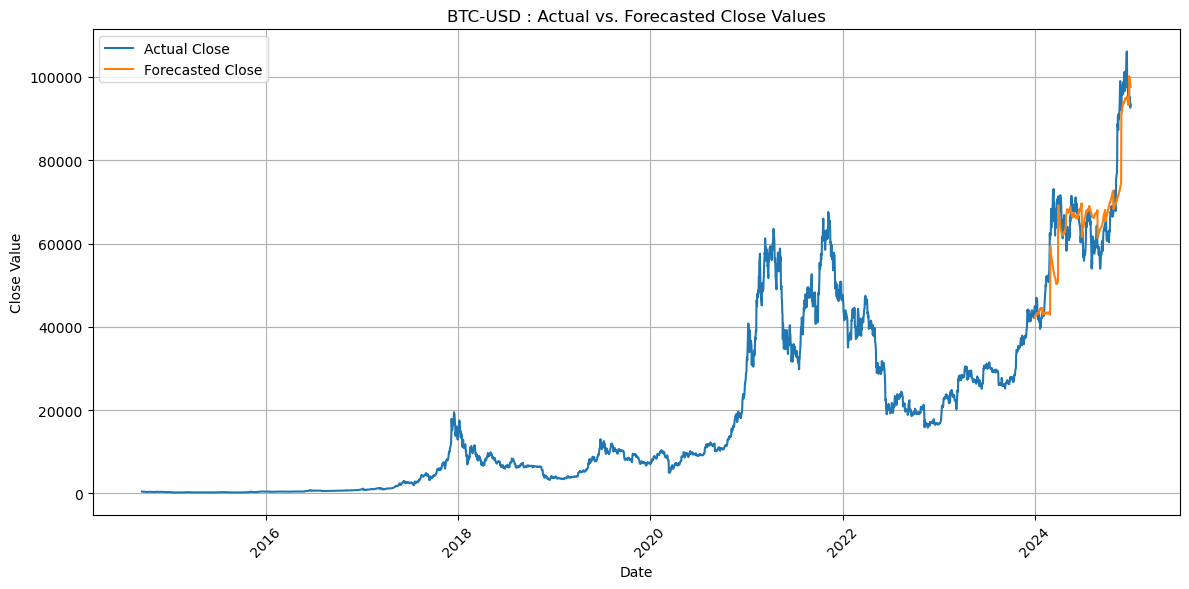

Evaluation Metric for BTC-USD_timesfm_30 Actual Values
MAPE: 8.65673845902194
ME: 1181.6526425887978
MAE: 5763.259797643443
MPE: 0.9923575501394696
RMSE: 7723.16937019225
R: 0.8564575427176795
Scalar Product: 12411252.191299438
Return Score: 0.5095890410958904
Long Return: 0.6210526315789474
Short Return: 0.38857142857142857
Mean Directional Accuracy: 0.5095890410958904
Mean Directional Accuracy Positive: 0.6210526315789474
Mean Directional Accuracy Negative: 0.38857142857142857
Execution time for forecast_crypto_prices(): 41.43878722190857 seconds


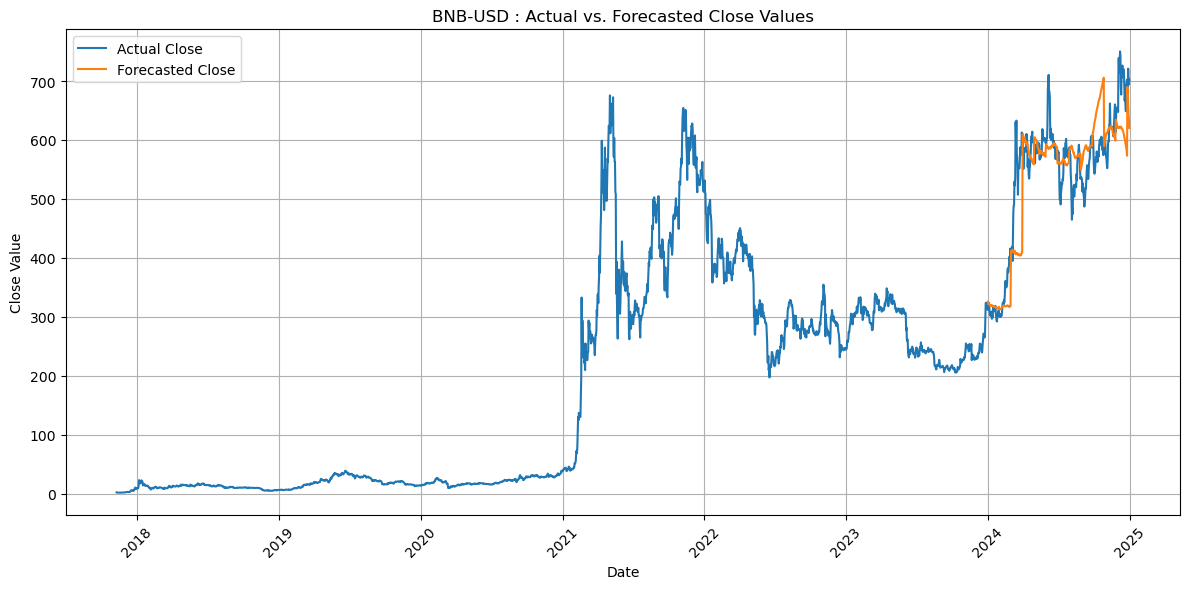

Evaluation Metric for BNB-USD_timesfm_30 Actual Values
MAPE: 8.011487688847076
ME: 7.599555093733991
MAE: 44.53969261294505
MPE: 0.9084210426713287
RMSE: 63.01314642143422
R: 0.8439532916626618
Scalar Product: -3356.5184430973604
Return Score: 0.4712328767123288
Long Return: 0.4607329842931937
Short Return: 0.4827586206896552
Mean Directional Accuracy: 0.4712328767123288
Mean Directional Accuracy Positive: 0.4607329842931937
Mean Directional Accuracy Negative: 0.4827586206896552
Execution time for forecast_crypto_prices(): 60.9308807849884 seconds


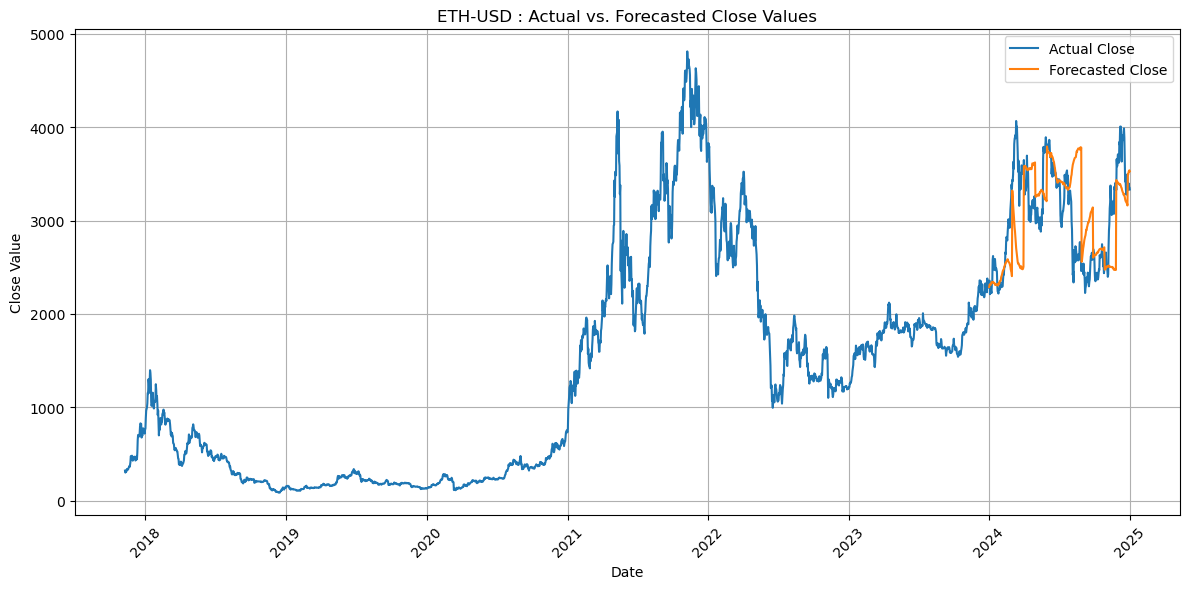

Evaluation Metric for ETH-USD_timesfm_30 Actual Values
MAPE: 12.736044061540323
ME: 1.612177947831284
MAE: 385.3562171810963
MPE: -1.518118423847812
RMSE: 517.3711823196232
R: 0.455289758152179
Scalar Product: -26698.667104959488
Return Score: 0.46301369863013697
Long Return: 0.45549738219895286
Short Return: 0.47126436781609193
Mean Directional Accuracy: 0.46301369863013697
Mean Directional Accuracy Positive: 0.45549738219895286
Mean Directional Accuracy Negative: 0.47126436781609193
Execution time for forecast_crypto_prices(): 80.21327567100525 seconds


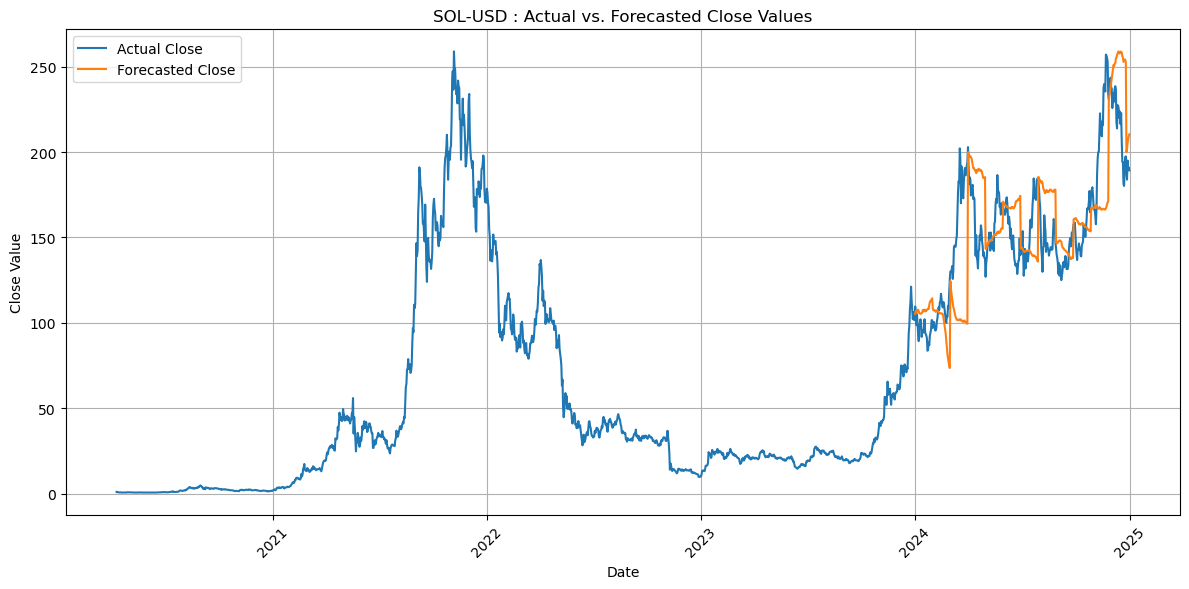

Evaluation Metric for SOL-USD_timesfm_30 Actual Values
MAPE: 14.978134401213437
ME: -0.48016536691801176
MAE: 24.008695842138405
MPE: -1.810515867544589
RMSE: 32.68408678430701
R: 0.6547059914192935
Scalar Product: 1910.9223366683038
Return Score: 0.4602739726027397
Long Return: 0.4088397790055249
Short Return: 0.5108695652173914
Mean Directional Accuracy: 0.4602739726027397
Mean Directional Accuracy Positive: 0.4088397790055249
Mean Directional Accuracy Negative: 0.5108695652173914


10466

In [38]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 30, freq='D', scaling = None)
gc.collect()

8b78c745-84d4-4e2e-9771-064252d1d9cb


Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=7, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 80.09625101089478 seconds


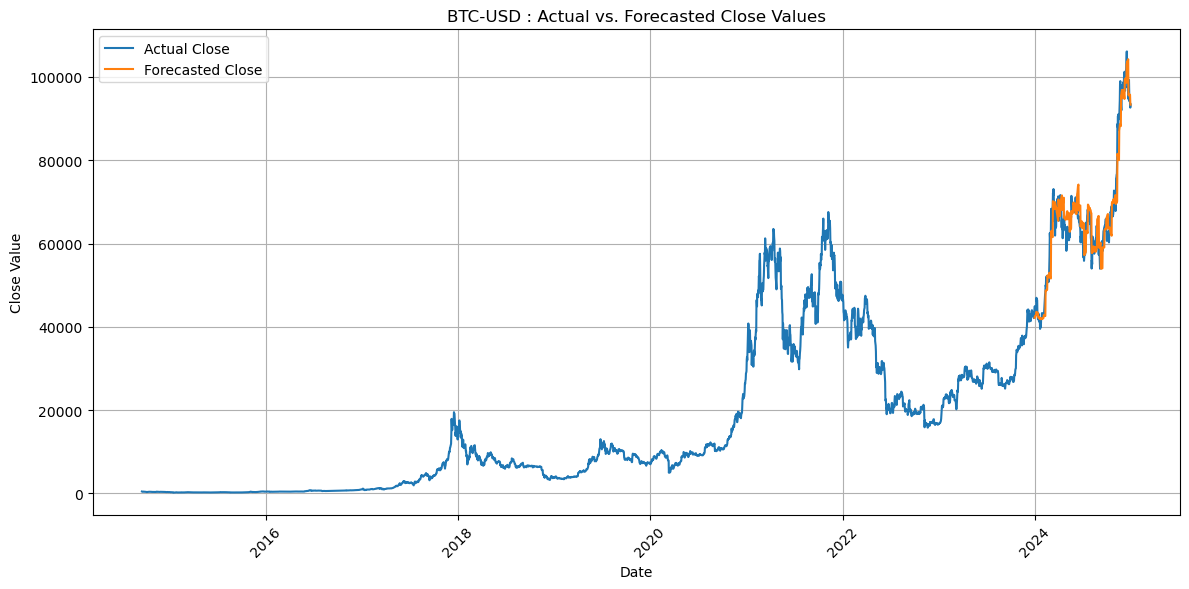

Evaluation Metric for BTC-USD_timesfm_7 Actual Values
MAPE: 5.009032026690893
ME: 75.7272562329235
MAE: 3295.2363921618853
MPE: -0.09374805641369248
RMSE: 4176.62923331501
R: 0.9588759834291224
Scalar Product: 175626978.54187012
Return Score: 0.4986301369863014
Long Return: 0.5421052631578948
Short Return: 0.4514285714285714
Mean Directional Accuracy: 0.4986301369863014
Mean Directional Accuracy Positive: 0.5421052631578948
Mean Directional Accuracy Negative: 0.4514285714285714
Execution time for forecast_crypto_prices(): 157.568843126297 seconds


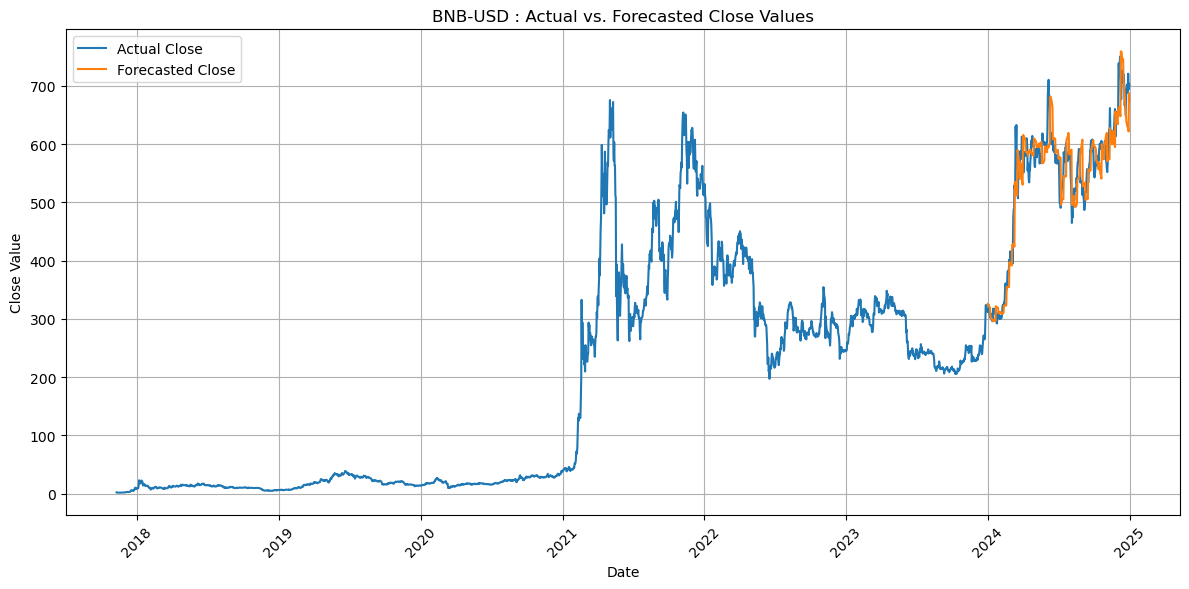

Evaluation Metric for BNB-USD_timesfm_7 Actual Values
MAPE: 5.167277438375548
ME: 3.9346768738793547
MAE: 28.687767320643356
MPE: 0.5243570641212918
RMSE: 37.323849175829636
R: 0.9438967748267616
Scalar Product: -12839.408661639318
Return Score: 0.4794520547945205
Long Return: 0.4293193717277487
Short Return: 0.5344827586206896
Mean Directional Accuracy: 0.4794520547945205
Mean Directional Accuracy Positive: 0.4293193717277487
Mean Directional Accuracy Negative: 0.5344827586206896
Execution time for forecast_crypto_prices(): 234.6472647190094 seconds


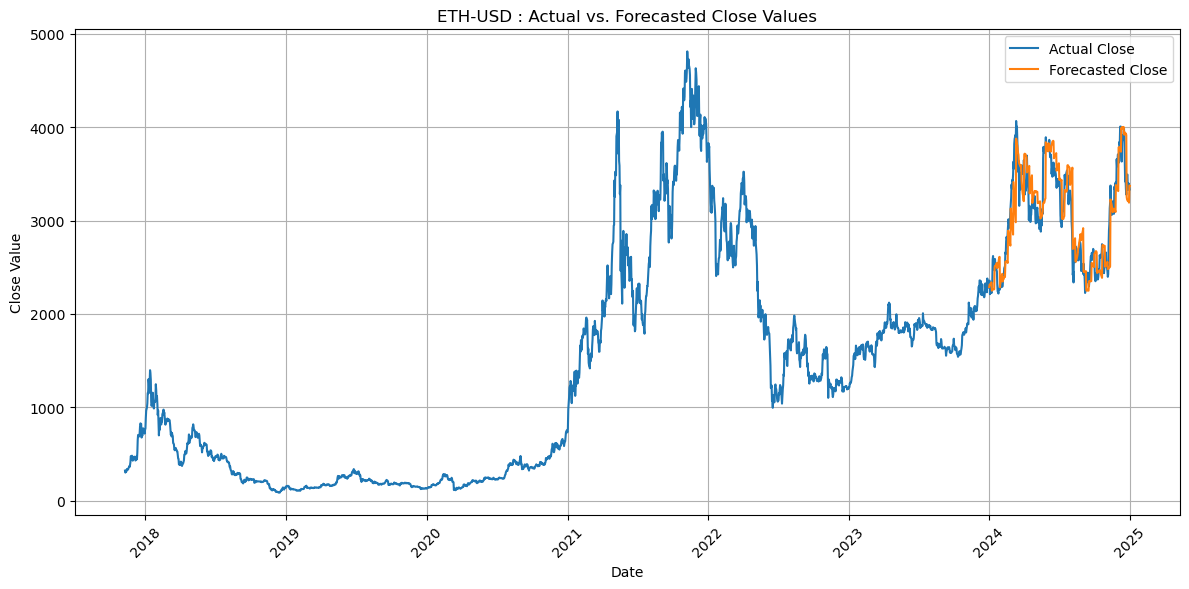

Evaluation Metric for ETH-USD_timesfm_7 Actual Values
MAPE: 6.431698223640218
ME: -17.162740405140028
MAE: 196.34186491419058
MPE: -0.8668593156448705
RMSE: 255.2012752228676
R: 0.8770794074828628
Scalar Product: 354544.73477214575
Return Score: 0.4821917808219178
Long Return: 0.5026178010471204
Short Return: 0.45977011494252873
Mean Directional Accuracy: 0.4821917808219178
Mean Directional Accuracy Positive: 0.5026178010471204
Mean Directional Accuracy Negative: 0.45977011494252873
Execution time for forecast_crypto_prices(): 311.9817109107971 seconds


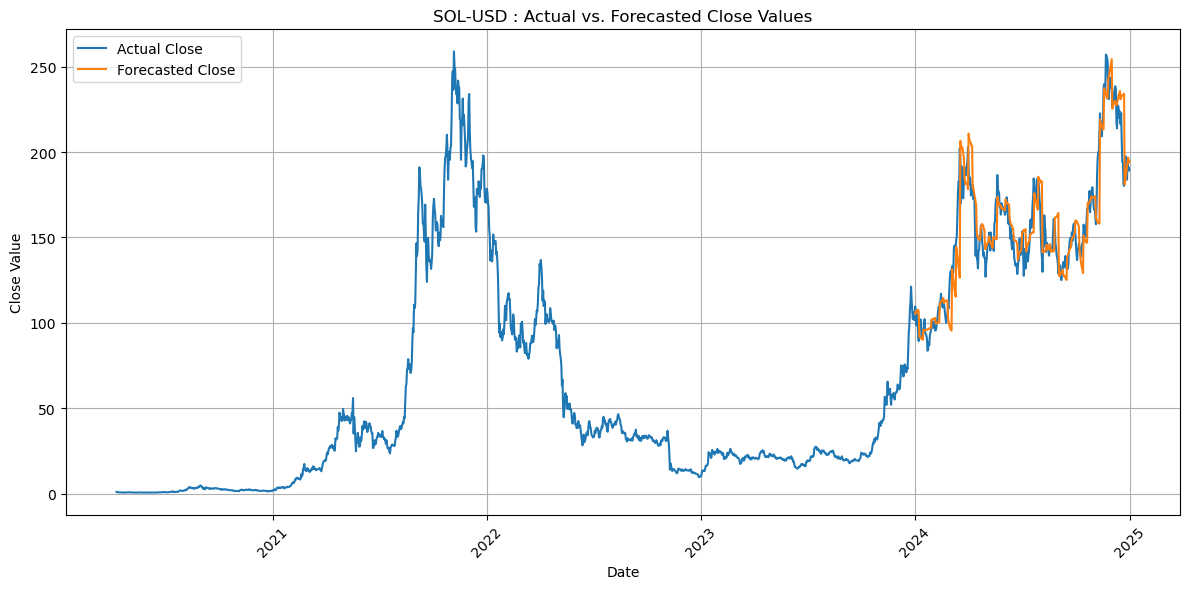

Evaluation Metric for SOL-USD_timesfm_7 Actual Values
MAPE: 6.731028954304817
ME: -0.7168188042979426
MAE: 10.448752689882706
MPE: -0.7974169405237616
RMSE: 15.112457270236643
R: 0.920250809668982
Scalar Product: 379.1410621810413
Return Score: 0.5315068493150685
Long Return: 0.5359116022099447
Short Return: 0.5271739130434783
Mean Directional Accuracy: 0.5315068493150685
Mean Directional Accuracy Positive: 0.5359116022099447
Mean Directional Accuracy Negative: 0.5271739130434783


20642

In [39]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 7, freq='D', scaling = None)
gc.collect()

55d6aa96-a267-499b-b9d7-9b78810cd81e


Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=1, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 518.7342693805695 seconds


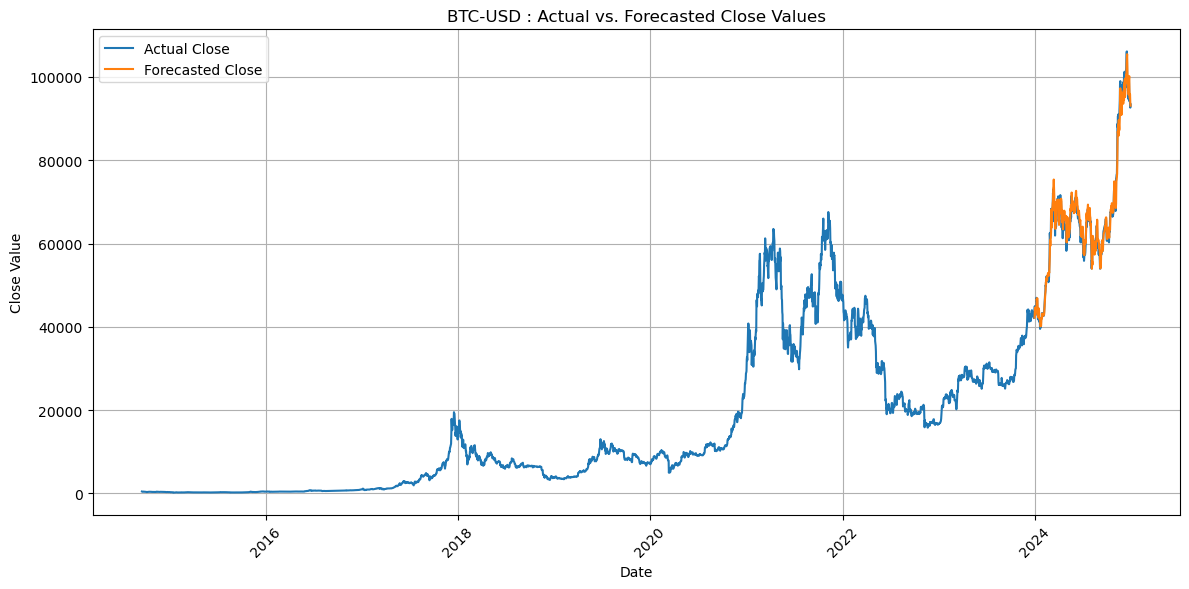

Evaluation Metric for BTC-USD_timesfm_1 Actual Values
MAPE: 2.536360224535554
ME: -305.0040663422131
MAE: 1688.050685194672
MPE: -0.622267990202761
RMSE: 2211.5484455988394
R: 0.9889294433268574
Scalar Product: -22417878.208190918
Return Score: 0.4876712328767123
Long Return: 0.5157894736842106
Short Return: 0.45714285714285713
Mean Directional Accuracy: 0.4876712328767123
Mean Directional Accuracy Positive: 0.5157894736842106
Mean Directional Accuracy Negative: 0.45714285714285713
Execution time for forecast_crypto_prices(): 1047.985464811325 seconds


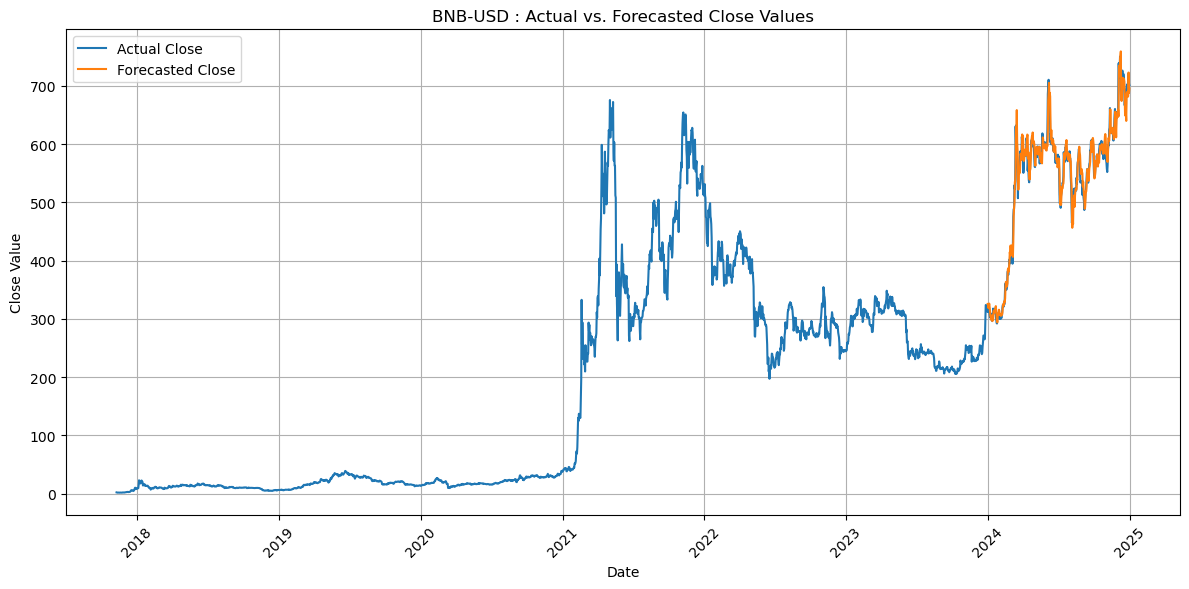

Evaluation Metric for BNB-USD_timesfm_1 Actual Values
MAPE: 2.4018099376268682
ME: -0.8366514945942196
MAE: 13.097512917440445
MPE: -0.26493421329269184
RMSE: 18.705423180901697
R: 0.9857728822469474
Scalar Product: -2820.1169982077563
Return Score: 0.4712328767123288
Long Return: 0.5235602094240838
Short Return: 0.41379310344827586
Mean Directional Accuracy: 0.4712328767123288
Mean Directional Accuracy Positive: 0.5235602094240838
Mean Directional Accuracy Negative: 0.41379310344827586
Execution time for forecast_crypto_prices(): 1577.310031414032 seconds


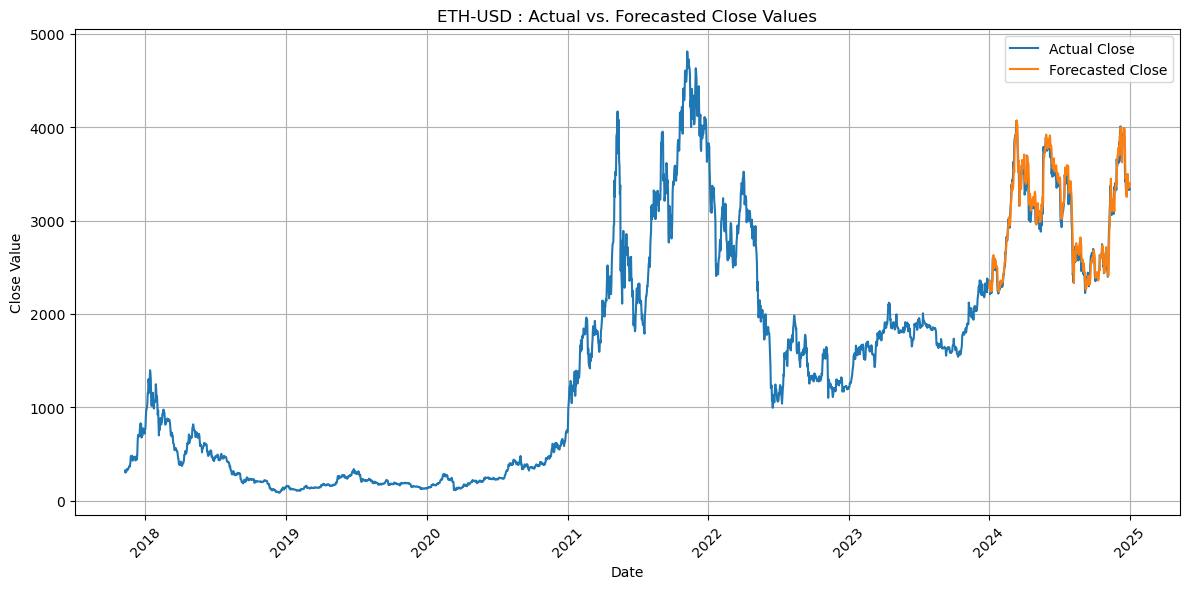

Evaluation Metric for ETH-USD_timesfm_1 Actual Values
MAPE: 2.9200964100450757
ME: -29.4584460649334
MAE: 89.08370488067794
MPE: -0.9997602169078462
RMSE: 118.75841821446515
R: 0.975125094537867
Scalar Product: -49548.81068056822
Return Score: 0.4547945205479452
Long Return: 0.49214659685863876
Short Return: 0.41379310344827586
Mean Directional Accuracy: 0.4547945205479452
Mean Directional Accuracy Positive: 0.49214659685863876
Mean Directional Accuracy Negative: 0.41379310344827586
Execution time for forecast_crypto_prices(): 2148.5196402072906 seconds


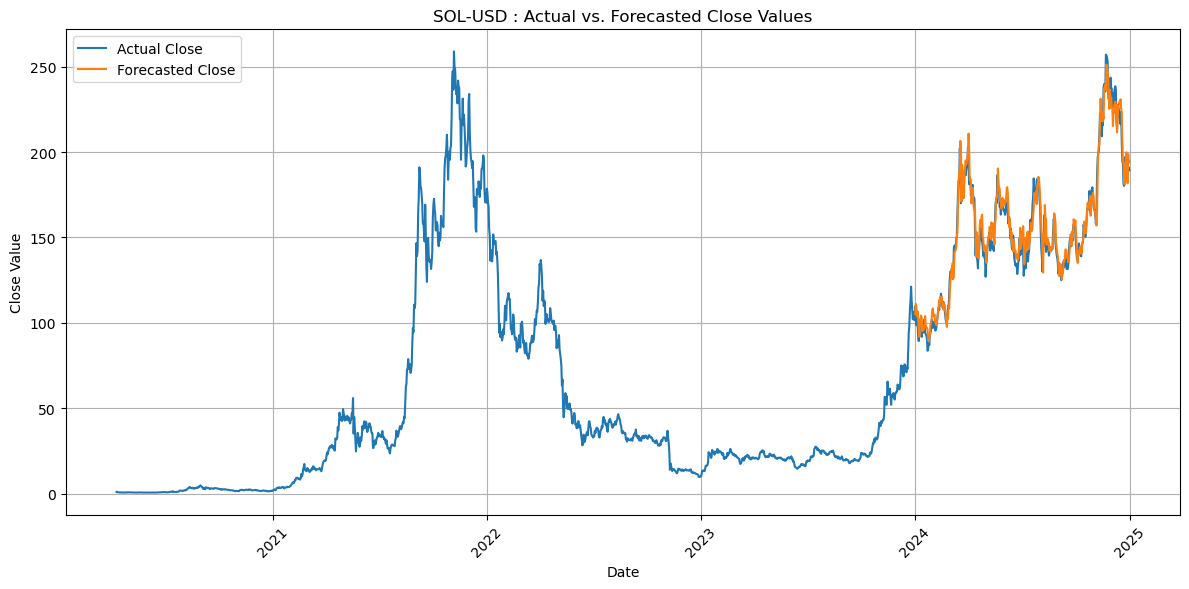

Evaluation Metric for SOL-USD_timesfm_1 Actual Values
MAPE: 3.99402487128898
ME: -1.5553773556902113
MAE: 6.09909941459614
MPE: -1.3431980540265298
RMSE: 7.804250189916151
R: 0.978722176458365
Scalar Product: -981.463834110179
Return Score: 0.5205479452054794
Long Return: 0.5193370165745856
Short Return: 0.5217391304347826
Mean Directional Accuracy: 0.5205479452054794
Mean Directional Accuracy Positive: 0.5193370165745856
Mean Directional Accuracy Negative: 0.5217391304347826


17096

In [40]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 1, freq='D', scaling = None)
gc.collect()